# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

Student: Gyan Bahadur Tamang  
Course: MSCS 634 — Big Data and Data Mining  
Assignment: Lab 3  

This notebook applies and compares K-Means and K-Medoids clustering on scikit-learn's Wine Dataset.

## Environment Setup

Run this cell first. Restart the kernel if packages are newly installed, then choose **Run All**.

In [7]:
# Install the packages required for the lab
%pip install -q pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1: Load and Prepare the Dataset

The dataset contains 178 observations, 13 numeric chemical features, and three known classes. Z-score normalization is necessary because distance-based clustering would otherwise be dominated by large-scale features such as proline.

In [8]:
# Import libraries for data loading, scaling, visualization, and clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset and separate features from known class labels
wine=load_wine()
X=pd.DataFrame(wine.data,columns=wine.feature_names)
y=pd.Series(wine.target,name='target')
print('Shape:',X.shape)
print('Features:',wine.feature_names)
print('Class distribution:')
print(y.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))
display(X.head())

# Standardize features so distance-based clustering treats each feature fairly
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print('Scaled means:',np.round(X_scaled.mean(axis=0),6))
print('Scaled standard deviations:',np.round(X_scaled.std(axis=0),6))

Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class distribution:
target
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Scaled means: [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Scaled standard deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2: Implement K-Means Clustering

K-Means uses k=3, multiple initializations, and a fixed seed. Silhouette measures cluster cohesion/separation; ARI compares assignments with the known classes while correcting for chance.

In [9]:
# Configure K-Means with three clusters and reproducible initialization
kmeans=KMeans(n_clusters=3,random_state=42,n_init=20)
# Assign each standardized observation to its nearest centroid
kmeans_labels=kmeans.fit_predict(X_scaled)
# Evaluate compactness and agreement with the known wine classes
kmeans_silhouette=silhouette_score(X_scaled,kmeans_labels)
kmeans_ari=adjusted_rand_score(y,kmeans_labels)
print('Cluster counts:',np.bincount(kmeans_labels))
print(f'Silhouette Score: {kmeans_silhouette:.4f}')
print(f'Adjusted Rand Index (ARI): {kmeans_ari:.4f}')

Cluster counts: [65 51 62]
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975


## Step 3: Implement K-Medoids Clustering

The function below implements alternating assignment and medoid-update steps. Unlike a centroid, every medoid is an actual observation. Deterministic initial medoids are selected as the most central observed points within preliminary partitions; updates minimize total within-cluster Euclidean distance.

In [10]:
# Implement K-Medoids using pairwise distances and actual observations as centers
def k_medoids(X,n_clusters=3,max_iter=100,random_state=42):
    # Precompute distances so assignments and medoid updates are efficient
    distances=pairwise_distances(X,metric='euclidean')
    # Use K-Means only to create deterministic preliminary groups
    initial=KMeans(n_clusters=n_clusters,random_state=random_state,n_init=20).fit_predict(X)
    medoids=[]
    for cluster in range(n_clusters):
        members=np.where(initial==cluster)[0]
        within=distances[np.ix_(members,members)]
        # Select the most central observation as the initial medoid
        medoids.append(int(members[np.argmin(within.sum(axis=1))]))
    for iteration in range(max_iter):
        # Assign each observation to its nearest current medoid
        labels=np.argmin(distances[:,medoids],axis=1)
        new_medoids=[]
        for cluster in range(n_clusters):
            members=np.where(labels==cluster)[0]
            within=distances[np.ix_(members,members)]
            # Update the medoid to minimize within-cluster distance
            new_medoids.append(int(members[np.argmin(within.sum(axis=1))]))
        if new_medoids==medoids:
            # Stop when the medoids no longer change
            break
        medoids=new_medoids
    return np.array(medoids),np.argmin(distances[:,medoids],axis=1),iteration+1

# Run K-Medoids and calculate its clustering metrics
medoid_indices,kmedoids_labels,iterations=k_medoids(X_scaled,n_clusters=3)
kmedoids_silhouette=silhouette_score(X_scaled,kmedoids_labels)
kmedoids_ari=adjusted_rand_score(y,kmedoids_labels)
print('Medoid indices:',medoid_indices)
print('Cluster counts:',np.bincount(kmedoids_labels))
print(f'Silhouette Score: {kmedoids_silhouette:.4f}')
print(f'Adjusted Rand Index (ARI): {kmedoids_ari:.4f}')

Medoid indices: [106 148  35]
Cluster counts: [55 49 74]
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411


## Step 4: Visualize and Compare Results

### 1. Side-by-Side Cluster Visualization

PCA reduces the standardized 13-dimensional feature space to two dimensions only for visualization. Models and metrics still use all 13 standardized features. Red X markers show projected K-Means centroids and actual K-Medoids observations.

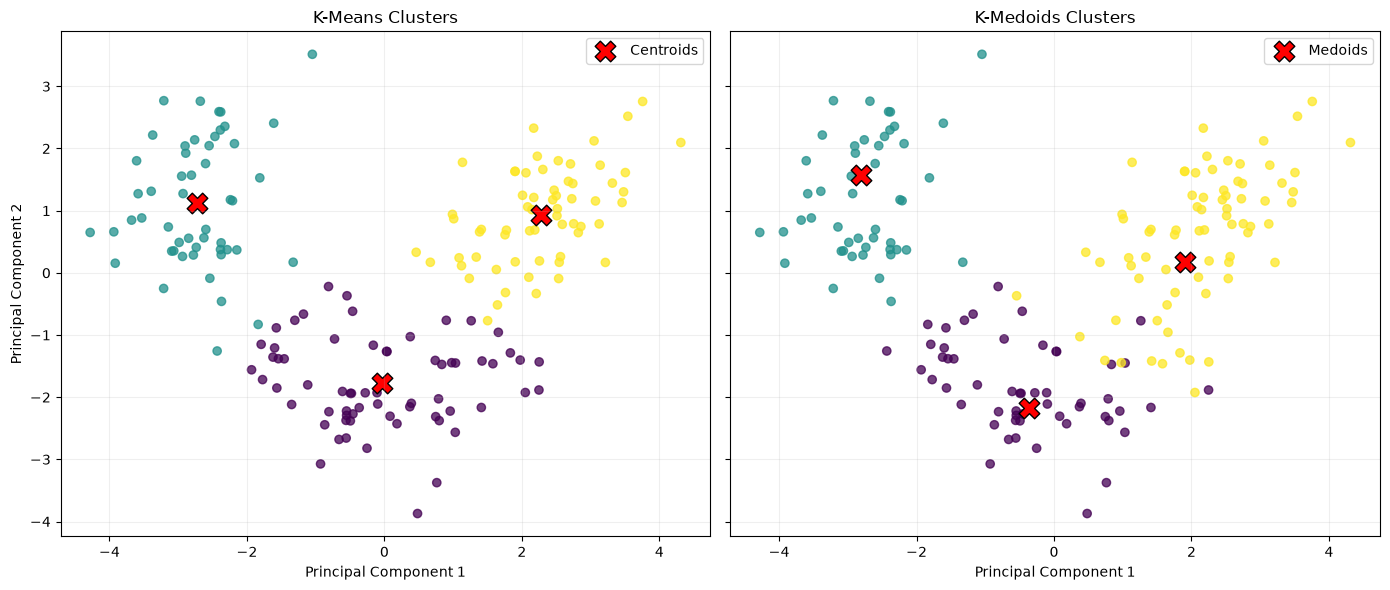

In [11]:
# Reduce the standardized feature space to two dimensions for plotting
pca=PCA(n_components=2)
X_2d=pca.fit_transform(X_scaled)
# Project K-Means centroids and retrieve the actual K-Medoids observations
kmeans_centers_2d=pca.transform(kmeans.cluster_centers_)
medoids_2d=X_2d[medoid_indices]
fig,axes=plt.subplots(1,2,figsize=(14,6),sharex=True,sharey=True)
# Plot both assignments with their corresponding center markers
for ax,labels,centers,title,name in [(axes[0],kmeans_labels,kmeans_centers_2d,'K-Means Clusters','Centroids'),(axes[1],kmedoids_labels,medoids_2d,'K-Medoids Clusters','Medoids')]:
    ax.scatter(X_2d[:,0],X_2d[:,1],c=labels,cmap='viridis',alpha=.75)
    ax.scatter(centers[:,0],centers[:,1],c='red',marker='X',s=220,edgecolor='black',label=name)
    ax.set_title(title); ax.set_xlabel('Principal Component 1'); ax.legend(); ax.grid(alpha=.2)
axes[0].set_ylabel('Principal Component 2')
plt.tight_layout(); plt.show()

### 2. Metric Comparison

In [12]:
# Place both algorithms' evaluation metrics in one comparison table
comparison=pd.DataFrame({'Algorithm':['K-Means','K-Medoids'],'Silhouette Score':[kmeans_silhouette,kmedoids_silhouette],'Adjusted Rand Index (ARI)':[kmeans_ari,kmedoids_ari]})
comparison

,Algorithm,Silhouette Score,Adjusted Rand Index (ARI)
0,K-Means,0.284859,0.897495
1,K-Medoids,0.267622,0.741137


### 3. Analysis and Algorithm Selection

**Which produced better-defined clusters?** K-Means produced the better-defined clusters: its Silhouette Score is **0.2849**, compared with **0.2676** for K-Medoids. It also matches the known wine classes more closely, with ARI **0.8975** versus **0.7411**.

**Cluster shapes and positioning.** In the PCA projection, K-Means creates more balanced, compact regions around freely positioned mean centroids. K-Medoids centers must be actual observations, shifting the boundaries and producing less balanced groups. PCA is only a two-dimensional view, so it does not display every separation present in the full feature space.

**When each is preferable.** K-Means is preferable for roughly compact clusters, Euclidean numeric features, and larger datasets because it is efficient. K-Medoids is preferable when robustness to extreme observations matters, when a representative real data point is required as each center, or when using a dissimilarity measure for which a numerical mean is not meaningful.

## Conclusion

Both methods reveal cluster structure after standardization, but K-Means performs better on both required metrics for this dataset and configuration. The experiment also highlights the conceptual difference between mean-based centroids and observation-based medoids.